 Extracting longitudinal radiomic sequences...
 Building integrated VHT Patient objects...


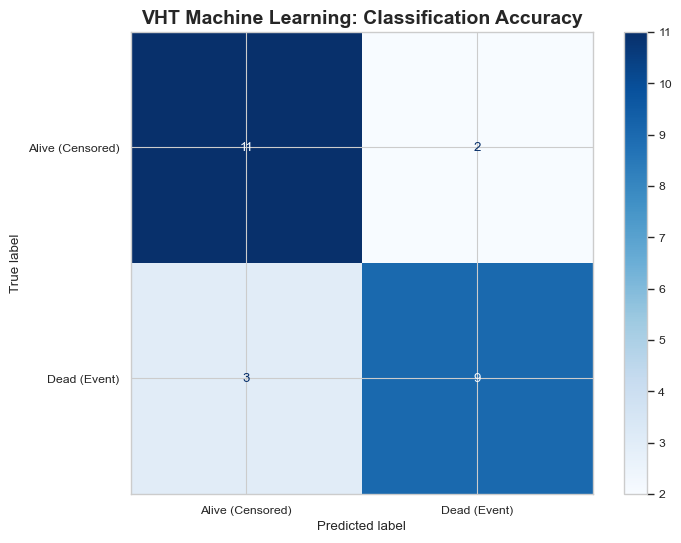

 VHT Matrix Complete: 178 components explain 99% variance.

 TOP DRIVERS OF VHT SIGNATURE (PC1):
Index(['Cycle length of Additional Therapy (q days)', 'Number of Fractions',
       'Number of Days from Diagnosis to Starting Additional Therapy ',
       'Number of days from Diagnosis to date of Further Progression',
       'Number of Days from Diagnosis to Starting 2nd_Additional Therapy ',
       'Multiple surgeries',
       'Number of Days from Diagnosis to Start Immunotherapy ',
       'Days from Diagnosis to new treatment',
       ' Number of days from Diagnosis to Initial Chemo Therapy end date',
       'Number of days from Diagnosis to date of First Progression',
       'Number of days from Diagnosis to Radiation Therapy end date',
       'Number of Days from Diagnosis to the day of Insertion of Brachytherapy ',
       ' Number of days from Diagnosis to Initial Chemo Therapy Start date',
       'Grade of Primary Brain Tumor',
       'Number of days from Diagnosis to Radiation Ther

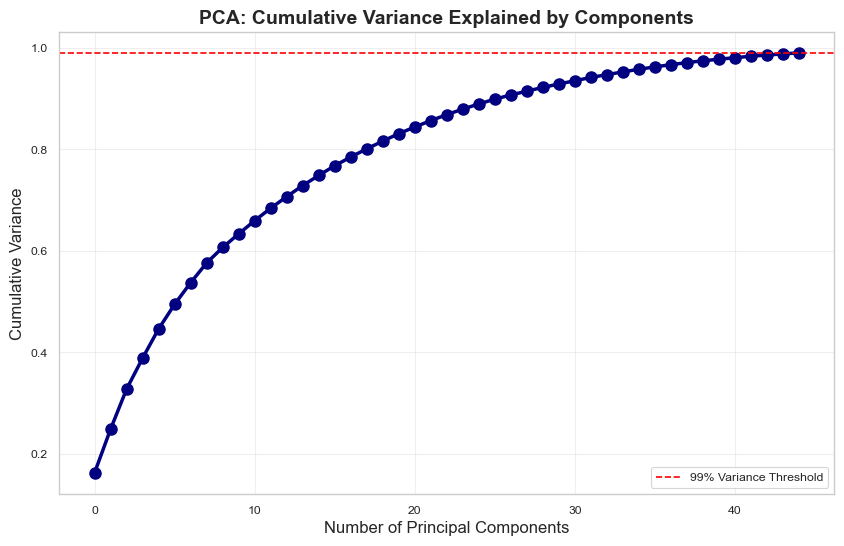

/var/folders/b9/x77syzb94gdggfcpp713pvjm0000gn/T/ipykernel_96803/3839154406.py:253: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=pc1_loadings.head(20).index, x=pc1_loadings.head(20).values, palette='viridis')


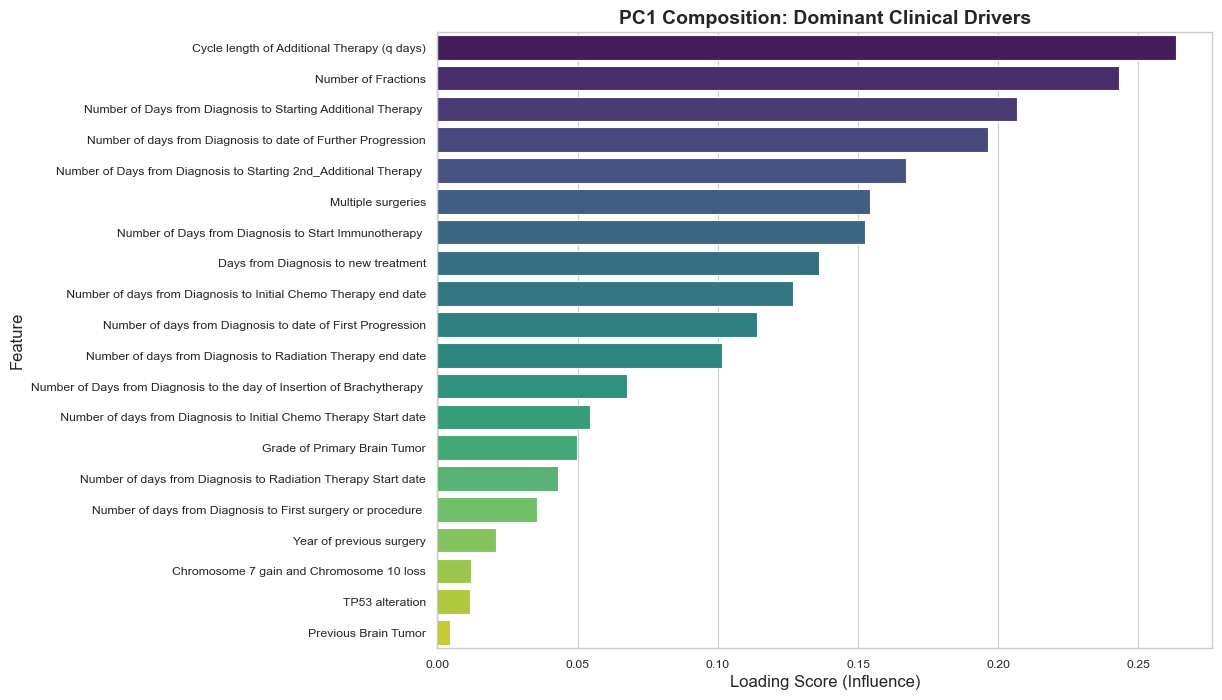

<lifelines.CoxPHFitter: fitted with 203 total observations, 106 right-censored observations>
             duration col = 'duration'
                event col = 'event'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 203
number of events observed = 97
   partial log-likelihood = -316.58
         time fit was run = 2026-06-07 17:45:49 UTC

---
                                                                         coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                                                                
Sex at Birth                                                            -0.09      0.91      0.24           -0.57            0.39                0.57                1.48
Race                                                                    -0.46      0.63      0.41           -1.26            0.34                0.28                1.40
Age at diagnosis                                                         0.00      1.00      0.01           -0.01            0.02                0.99                1.02
Primary Diagnosis                                                       -0.01      0.99      0.21           -0.41            0.40                0.66                1.48
Grade of Primary Brain Tumor                                             0.04      1.04      0.24           -0.43            0.50                0.65                1.65
Stereotactic Biopsy before Surgical Resection                            0.69      1.98      0.49           -0.27            1.64                0.76                5.16
Multiple surgeries                                                      -0.50      0.61      0.28           -1.05            0.05                0.35                1.05
IDH1 mutation                                                            0.23      1.26      0.30           -0.36            0.82                0.70                2.26
IDH2 mutation                                                            0.07      1.08      0.24           -0.39            0.54                0.67                1.72
1p/19q                                                                   0.03      1.03      0.03           -0.03            0.09                0.97                1.09
ATRX mutation                                                           -0.04      0.96      0.08           -0.19            0.11                0.82                1.11
MGMT methylation                                                        -0.16      0.85      0.09           -0.35            0.02                0.71                1.02
BRAF V600E mutation                                                      0.11      1.11      0.64           -1.15            1.37                0.32                3.92
TERT promoter mutation                                                   0.01      1.01      0.33           -0.64            0.66                0.53                1.94
Chromosome 7 gain and Chromosome 10 loss                                -0.63      0.53      0.55           -1.70            0.45                0.18                1.56
H3-3A mutation                                                          -0.02      0.98      0.24           -0.49            0.44                0.61                1.55
EGFR amplification                                                       0.35      1.42      0.51           -0.65            1.35                0.52                3.87
PTEN mutation                                                            0.04      1.04      0.56           -1.06            1.14                0.35                3.11
CDKN2A/B deletion                                                        0.14      1.15      0.65           -1.14            1.41                0.32                4.09
TP53 a

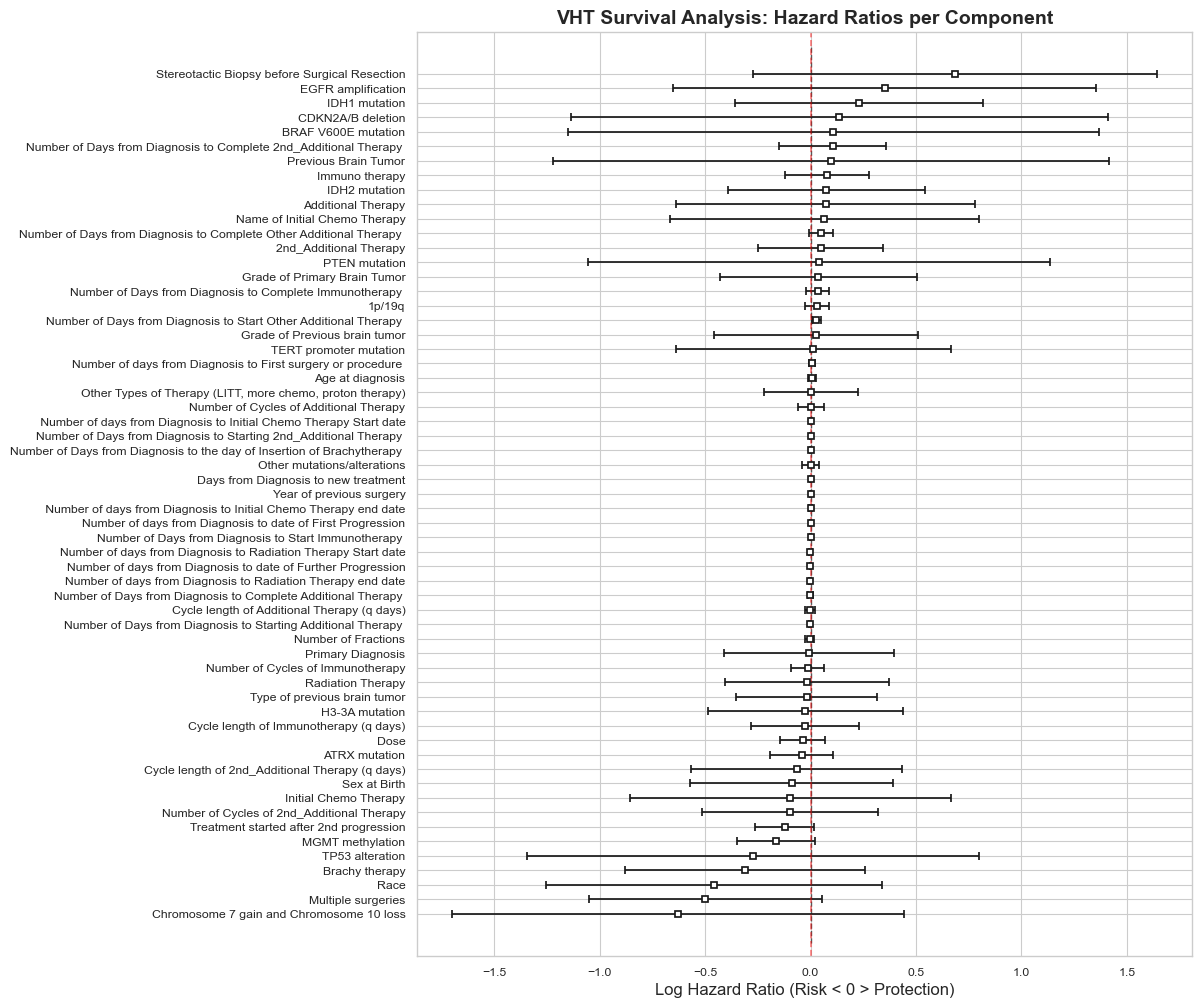

In [9]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from lifelines import CoxPHFitter
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


# ======================================================================================
# 1. SETUP & LONGITUDINAL EXTRACTION
# ======================================================================================
image_path = Path("/Users/kasunachinthaperera/Documents/Final Year Project:Thesis/Data/PKG - MU-Glioma-Post/MU-Glioma-Post")
seg_vol_path = Path("/Users/kasunachinthaperera/Documents/Final Year Project:Thesis/Data/PKG - MU-Glioma-Post/MU-Glioma-Post_Segmentation_Volumes.xlsx")
clinical_path = Path("/Users/kasunachinthaperera/Documents/Final Year Project:Thesis/Data/PKG - MU-Glioma-Post/MU-Glioma-Post_ClinicalData-July2025.xlsx")

segmentation_labels = {1: "Necrotic", 2: "Edema", 3: "Enhancing", 4: "Resection"}
label_map = {
    "Necrotic Tumor Core (Label1)": "Necrotic",
    "Tumor Infiltration and Edema": "Edema",
    "Enhancing Tumor Core (Label3)": "Enhancing",
    "Resection Cavity (Label4)": "Resection"
}


def safe_numeric(s, default=np.nan):
    """Safely converts a pandas Series to a numeric data type, filling unconvertible records.

    This function attempts to parse input objects into numeric float values. If the
    input is a pandas Series, any parsing errors (e.g., string text or invalid dates)
    will be coerced into NaNs and subsequently filled with the specified default value.
    Non-Series inputs are returned unmodified.

    Args:
        s (pd.Series or any): The target entity or sequence to convert into numeric form.
        default (float, optional): The fallback value to substitute for unparseable or 
            missing data points. Defaults to np.nan.

    Returns:
        pd.Series or any: A numeric pandas Series with filled missing values if the input 
            was a Series; otherwise, returns the original input object.
    """
    return pd.to_numeric(s, errors='coerce').fillna(default) if isinstance(s, pd.Series) else s


# ======================================================================================
# 2. LOAD RADIOMIC MASTER SEQUENCES
# ======================================================================================
"""Parses multi-sequence radiomic segmentation metrics and integrates them with clinical profiles.

    Iterates over all sheets within the radiomic Excel file, groups the sequential volume 
    and intensity features by patient, merges them with static row-indexed clinical history, 
    and synchronizes the parameters with cross-sectional NIfTI imaging directories.

    Args:
        seg_vol_path (str or Path): Path to the master Excel file containing longitudinal 
            segmentation volumes and sequence intensities across multiple sheets.
        clinical_path (str or Path): Path to the clinical sheet containing demographic, 
            molecular, and baseline diagnostic data.
        image_path (str or Path): Root directory housing physical cross-sectional patient 
            folders and their respective longitudinal timepoint scans.
        label_map (dict): Dictionary mapping raw Excel sheet titles to uniform target tissue 
            compartments (e.g., 'Necrotic', 'Edema', 'Enhancing', 'Resection').

    Returns:
        tuple: A tuple containing:
            - patient_objects (dict): A deeply nested dictionary mapping clean Patient IDs 
              to their integrated timeline arrays, sequence means, standard deviations, and clinical indices.
            - clinical_df (pd.DataFrame): The raw loaded master clinical database.
    """
print(" Extracting longitudinal radiomic sequences...")
m_dict = {k: {} for k in ['vol', 'vox', 't1cm', 't1cs', 't1nm', 't1ns', 't2fm', 't2fs', 't2wm', 't2ws']}

seg_file = pd.ExcelFile(seg_vol_path)
for sheet in seg_file.sheet_names:
    df = pd.read_excel(seg_vol_path, sheet_name=sheet)
    df.columns = df.columns.str.strip()

    if 'Patient ID' not in df.columns:
        continue

    df['PID_Clean'] = df['Patient ID'].astype(str).str.split('-').str[0]
    label_key = label_map.get(sheet, sheet)
    group = df.groupby('PID_Clean')

    cols = list(df.columns)
    if len(cols) < 13:
        continue

    m_dict['vox'][label_key]  = group[cols[3]].apply(list).to_dict()
    m_dict['vol'][label_key]  = group[cols[4]].apply(list).to_dict()
    m_dict['t1cm'][label_key] = group[cols[5]].apply(list).to_dict()
    m_dict['t1cs'][label_key] = group[cols[6]].apply(list).to_dict()
    m_dict['t1nm'][label_key] = group[cols[7]].apply(list).to_dict()
    m_dict['t1ns'][label_key] = group[cols[8]].apply(list).to_dict()
    m_dict['t2fm'][label_key] = group[cols[9]].apply(list).to_dict()
    m_dict['t2fs'][label_key] = group[cols[10]].apply(list).to_dict()
    m_dict['t2wm'][label_key] = group[cols[11]].apply(list).to_dict()
    m_dict['t2ws'][label_key] = group[cols[12]].apply(list).to_dict()

clinical_df = pd.read_excel(clinical_path, sheet_name='MU Glioma Post')
clinical_df['PID_Clean'] = clinical_df['Patient ID'].astype(str).str.split('-').str[0]
clinical_data = clinical_df.set_index('PID_Clean').to_dict(orient='index')

patient_ids = sorted([d for d in os.listdir(image_path) if (image_path / d).is_dir() and not d.startswith('.')])
patient_objects = {}

print(" Building integrated VHT Patient objects...")
for pid in patient_ids:
    clean_id = pid.split('-')[0]
    p_folder = image_path / pid
    tps = sorted([t.name for t in p_folder.iterdir() if t.is_dir() and not t.name.startswith('.')])

    obj = {
        'Patient_ID': pid,
        'PID_Clean': clean_id,
        'clinical': clinical_data.get(clean_id, {}),
        'timepoints': tps,
        'images': {}, 'volumes': {}, 'voxels': {},
        't1c_mean': {}, 't1c_stdevs': {}, 't1n_mean': {}, 't1n_stdevs': {},
        't2f_mean': {}, 't2f_stdevs': {}, 't2w_mean': {}, 't2w_stdevs': {}
    }

    for i, tp in enumerate(tps):
        obj['images'][tp] = [str(f) for f in (p_folder / tp).glob("*.nii*")]
        for l_name in m_dict['vol'].keys():
            def get_val(key):
                seq = m_dict[key].get(l_name, {}).get(clean_id, [])
                return seq[i] if i < len(seq) else 0

            obj['volumes'].setdefault(tp, {})[l_name] = float(get_val('vol'))
            obj['voxels'].setdefault(tp, {})[l_name] = int(get_val('vox'))
            obj['t1c_mean'].setdefault(tp, {})[l_name] = float(get_val('t1cm'))
            obj['t1c_stdevs'].setdefault(tp, {})[l_name] = float(get_val('t1cs'))
            obj['t1n_mean'].setdefault(tp, {})[l_name] = float(get_val('t1nm'))
            obj['t1n_stdevs'].setdefault(tp, {})[l_name] = float(get_val('t1ns'))
            obj['t2f_mean'].setdefault(tp, {})[l_name] = float(get_val('t2fm'))
            obj['t2f_stdevs'].setdefault(tp, {})[l_name] = float(get_val('t2fs'))
            obj['t2w_mean'].setdefault(tp, {})[l_name] = float(get_val('t2wm'))
            obj['t2w_stdevs'].setdefault(tp, {})[l_name] = float(get_val('t2ws'))

    patient_objects[pid] = obj


# ======================================================================================
# 3. MERGING & CLEANING FOR ML
# ======================================================================================
"""Encodes categorical data, performs PCA dimension reduction, and trains a Gradient Boosting Classifier.

    This block drops forbidden downstream target and outcome metrics, applies label-encoding 
    to text categories, filters down to finite survival records, splits rows into train/test variants, 
    scales features uniformly, reduces input features into an optimal orthogonal principal component 
    matrix capturing 99% variance, and fits an ensemble classification tree.

    Args:
        clinical_df (pd.DataFrame): The raw dataframe containing patient records.
        targets (list of str): List containing target outcome labels (e.g., event status and survival durations).
        exclude (list of str): Complete list of features, timelines, or progression attributes 
            to drop from the feature matrix to prevent data leakage.
        test_size (float, optional): Proportion of the dataset to allocate to the validation split. Defaults to 0.12.
        random_state (int, optional): The seed modifier to enforce deterministic train-test partitions. Defaults to 42.

    Returns:
        tuple: A tuple containing:
            - clf_pca (GradientBoostingClassifier): The trained gradient boosting model estimator.
            - pca (PCA): The fitted Principal Component Analysis reduction model.
            - scaler (StandardScaler): The fitted mean/variance standardization matrix.
            - evaluation_data (tuple): Contains processed arrays (X_test_pca, y_test) ready for validation.
    """
df_vht = clinical_df.copy()

targets = ['Overall Survival (Death)', 'Number of days from Diagnosis to death (Days)']
exclude = targets + [
    'Patient ID', 'PID_Clean', 'Hospice', 'Time to First Progression (Days)', 'Progression',
    'Type of 1st Progression', 'Second Progression/Recurrence', 'Type of 2nd Progression',
    'Number of Days from Diagnosis to 1st MRI (Timepoint_1) ',
    'Number of Days from Diagnosis to 2nd MRI (Timepoint_2) ',
    'Number of Days from Diagnosis to 3rd MRI (Timepoint_3) ',
    'Number of Days from Diagnosis to 4th MRI (Timepoint_4) ',
    'Number of Days from Diagnosis to 5th MRI (Timepoint_5) ',
    'Number of Days from Diagnosis to 6th MRI (Timepoint_6) '
]

X_raw = df_vht.drop(columns=[c for c in exclude if c in df_vht.columns]).copy()

for col in X_raw.select_dtypes(include=['object']).columns:
    X_raw[col] = LabelEncoder().fit_transform(X_raw[col].astype(str))
X_raw = X_raw.fillna(0)

y_labels = pd.to_numeric(df_vht[targets[0]], errors='coerce').fillna(0).astype(int)
surv_duration = pd.to_numeric(df_vht[targets[1]], errors='coerce').fillna(1).astype(float)
surv_event = y_labels.copy()

valid_rows = np.isfinite(surv_duration.values)
X_raw = X_raw.loc[valid_rows].reset_index(drop=True)
y_labels = y_labels.loc[valid_rows].reset_index(drop=True)
surv_duration = surv_duration.loc[valid_rows].reset_index(drop=True)
surv_event = surv_event.loc[valid_rows].reset_index(drop=True)
df_vht = df_vht.loc[valid_rows].reset_index(drop=True)

X_train_raw, X_test_raw, y_train, y_test, dur_train, dur_test, evt_train, evt_test = train_test_split(
    X_raw, y_labels, surv_duration, surv_event,
    test_size=0.12, random_state=42, stratify=y_labels
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

pca = PCA(n_components=0.99, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

clf_pca = GradientBoostingClassifier(n_estimators=150, learning_rate=0.1, max_depth=4, random_state=42)
clf_pca.fit(X_train_pca, y_train)

y_pred = clf_pca.predict(X_test_pca)
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Alive (Censored)', 'Dead (Event)'])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', values_format='d', ax=ax)
plt.title('VHT Machine Learning: Classification Accuracy', fontsize=14, fontweight='bold')
plt.show()


# ======================================================================================
# 4. VHT SIGNATURE ANALYSIS (PCA)
# ======================================================================================
print(f" VHT Matrix Complete: {X_train_pca.shape[0]} components explain 99% variance.")

pc1_drivers = pd.Series(pca.components_[0], index=X_raw.columns).sort_values(ascending=False)
print("\n TOP DRIVERS OF VHT SIGNATURE (PC1):")
print(pc1_drivers.head(20).index)

plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_), 'o-', color='navy', linewidth=2.5, markersize=8)
plt.axhline(y=0.99, color='red', linestyle='--', label='99% Variance Threshold')
plt.title('PCA: Cumulative Variance Explained by Components', fontsize=14, fontweight='bold')
plt.xlabel('Number of Principal Components', fontsize=12)
plt.ylabel('Cumulative Variance', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10, 8))
pc1_loadings = pd.Series(pca.components_[0], index=X_raw.columns).sort_values(ascending=False)
sns.barplot(y=pc1_loadings.head(20).index, x=pc1_loadings.head(20).values, palette='viridis')
plt.title('PC1 Composition: Dominant Clinical Drivers', fontsize=14, fontweight='bold')
plt.xlabel('Loading Score (Influence)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.axvline(0, color='black', linewidth=0.8)
plt.show()


# ======================================================================================
# 5. SURVIVAL MODELING (COX PCA)
# ======================================================================================
"""Fits a semi-parametric Cox Proportional Hazards regression model to estimate covariate risk.

    Consolidates the cleaned data matrices into a unified survival dataframe containing 
    covariates alongside continuous time-to-event outcomes. Filters out zero or negative duration values, 
    drops non-numeric elements, and runs regularized partial-likelihood estimation to calculate 
    Hazard Ratios (HR) for the extracted components.

    Args:
        X_raw (pd.DataFrame): Cleaned, label-encoded numeric feature dataframe.
        surv_duration (pd.Series or np.ndarray): Continuous numeric vector denoting 
            the number of days from baseline diagnosis to death or right-censoring.
        surv_event (pd.Series or np.ndarray): Binary event indicator where 1 represents 
            death (event occurrence) and 0 represents censored (alive at last contact).
        penalizer (float, optional): L2 ridge regularization parameter added to the 
            Cox log-partial likelihood function to prevent parameter exploding. Defaults to 0.1.

    Returns:
        CoxPHFitter: A trained semi-parametric survival model object containing hazard ratios, 
            confidence intervals, coefficients, and log-likelihood statistics.
    """
df_cox_pca = pd.DataFrame(X_raw.values, columns=X_raw.columns)
df_cox_pca['duration'] = surv_duration.values
df_cox_pca['event'] = surv_event.values

cox_df = df_cox_pca.drop(columns=[], errors='ignore').copy()
cox_df = cox_df.select_dtypes(include=[np.number]).copy()
cox_df = cox_df.dropna(subset=['duration', 'event'])
cox_df = cox_df[cox_df['duration'] > 0]

cph = CoxPHFitter(penalizer=0.1)
cph.fit(cox_df, duration_col='duration', event_col='event')
cph.print_summary()

# --- NEW: Link Patient IDs and extract Individual Risk Scores ---
# 1. Bring the patient IDs back into this dataframe using the index alignment
df_cox_pca['PID_Clean'] = df_vht['PID_Clean'].values

# 2. Compute individual mathematical risk scores (Partial Hazards: exp(βX))
df_cox_pca['risk_score'] = cph.predict_partial_hazard(cox_df)

# 3. Fallback: If any patient was filtered out by the Cox engine, give them a baseline risk of 1.0
df_cox_pca['risk_score'] = df_cox_pca['risk_score'].fillna(1.0)

# 4. Display the distribution of risk scores across the cohort
plt.figure(figsize=(10, 12))
cph.plot()
plt.title('VHT Survival Analysis: Hazard Ratios per Component', fontsize=14, fontweight='bold')
plt.xlabel('Log Hazard Ratio (Risk < 0 > Protection)', fontsize=12)
plt.axvline(0, color='red', linestyle='--', alpha=0.5)
plt.show()

In [10]:
import os
import numpy as np
import pandas as pd
import nibabel as nib
from pathlib import Path
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.multioutput import MultiOutputRegressor

image_path = Path("/Users/kasunachinthaperera/Documents/Final Year Project:Thesis/Data/PKG - MU-Glioma-Post/MU-Glioma-Post")
seg_vol_path = Path("/Users/kasunachinthaperera/Documents/Final Year Project:Thesis/Data/PKG - MU-Glioma-Post/MU-Glioma-Post_Segmentation_Volumes.xlsx")
clinical_path = Path("/Users/kasunachinthaperera/Documents/Final Year Project:Thesis/Data/PKG - MU-Glioma-Post/MU-Glioma-Post_ClinicalData-July2025.xlsx")

label_map = label_map if "label_map" in globals() else {}

# ======================================================================================
# 1. LOAD RADIOMIC MASTER SEQUENCES (Ordered by Patient/Visit)
# ======================================================================================
print("Extracting longitudinal radiomic sequences...")

metrics = ['vol', 'vox', 't1cm', 't1cs', 't1nm', 't1ns', 't2fm', 't2fs', 't2wm', 't2ws']
m_dict = {k: {} for k in metrics}

seg_file = pd.ExcelFile(seg_vol_path)

for sheet in seg_file.sheet_names:
    df = pd.read_excel(seg_vol_path, sheet_name=sheet)
    df.columns = df.columns.str.strip()

    """if 'Patient ID' not in df.columns or len(df.columns) < 13:
        continue"""

    df = df.copy()
    df['PID_Clean'] = df['Patient ID'].astype(str).str.split('-').str[0]
    label_key = label_map.get(sheet, sheet)

    group = df.groupby('PID_Clean', dropna=False)

    col_map = {
        'vox': df.columns[3],
        'vol': df.columns[4],
        't1cm': df.columns[5],
        't1cs': df.columns[6],
        't1nm': df.columns[7],
        't1ns': df.columns[8],
        't2fm': df.columns[9],
        't2fs': df.columns[10],
        't2wm': df.columns[11],
        't2ws': df.columns[12],
    }

    for metric, col_name in col_map.items():
        m_dict[metric][label_key] = group[col_name].apply(list).to_dict()

clinical_df = pd.read_excel(clinical_path, sheet_name='MU Glioma Post')
clinical_df['PID_Clean'] = clinical_df['Patient ID'].astype(str).str.split('-').str[0]
clinical_data = clinical_df.set_index('PID_Clean').to_dict(orient='index')

# ======================================================================================
# 2. BUILD INTEGRATED VHT PATIENT OBJECTS
# ======================================================================================
def tp_index(tp):
    digits = ''.join(filter(str.isdigit, str(tp)))
    return int(digits) if digits else 10**9

patient_ids = sorted([
    d for d in os.listdir(image_path)
    if (image_path / d).is_dir() and not d.startswith('.')
])

patient_objects = {}

print("Building integrated VHT patient objects...")

for pid in patient_ids:
    clean_id = pid.split('-')[0]
    p_folder = image_path / pid

    tps = [
        t.name for t in p_folder.iterdir()
        if t.is_dir() and not t.name.startswith('.')
    ]
    tps = sorted(tps, key=tp_index)

    if len(tps) < 2:
        continue

    obj = {
        'Patient_ID': pid,
        'PID_Clean': clean_id,
        'clinical': clinical_data.get(clean_id, {}),
        'timepoints': tps,
        'images': {},
        'volumes': {},
        'voxels': {},
        't1c_mean': {},
        't1c_stdevs': {},
        't1n_mean': {},
        't1n_stdevs': {},
        't2f_mean': {},
        't2f_stdevs': {},
        't2w_mean': {},
        't2w_stdevs': {}
    }

    for i, tp in enumerate(tps):
        tp_folder = p_folder / tp
        obj['images'][tp] = [str(f) for f in tp_folder.glob("*.nii*")]

        for l_name in m_dict['vol'].keys():
            def get_val(key):
                seq = m_dict[key].get(l_name, {}).get(clean_id, [])
                return seq[i] if i < len(seq) else np.nan

            obj['volumes'].setdefault(tp, {})[l_name] = float(get_val('vol')) if pd.notna(get_val('vol')) else np.nan
            obj['voxels'].setdefault(tp, {})[l_name] = int(get_val('vox')) if pd.notna(get_val('vox')) else 0
            obj['t1c_mean'].setdefault(tp, {})[l_name] = float(get_val('t1cm')) if pd.notna(get_val('t1cm')) else np.nan
            obj['t1c_stdevs'].setdefault(tp, {})[l_name] = float(get_val('t1cs')) if pd.notna(get_val('t1cs')) else np.nan
            obj['t1n_mean'].setdefault(tp, {})[l_name] = float(get_val('t1nm')) if pd.notna(get_val('t1nm')) else np.nan
            obj['t1n_stdevs'].setdefault(tp, {})[l_name] = float(get_val('t1ns')) if pd.notna(get_val('t1ns')) else np.nan
            obj['t2f_mean'].setdefault(tp, {})[l_name] = float(get_val('t2fm')) if pd.notna(get_val('t2fm')) else np.nan
            obj['t2f_stdevs'].setdefault(tp, {})[l_name] = float(get_val('t2fs')) if pd.notna(get_val('t2fs')) else np.nan
            obj['t2w_mean'].setdefault(tp, {})[l_name] = float(get_val('t2wm')) if pd.notna(get_val('t2wm')) else np.nan
            obj['t2w_stdevs'].setdefault(tp, {})[l_name] = float(get_val('t2ws')) if pd.notna(get_val('t2ws')) else np.nan

    patient_objects[pid] = obj

print(f"Built {len(patient_objects)} longitudinal patient objects.")

Extracting longitudinal radiomic sequences...
Building integrated VHT patient objects...
Built 155 longitudinal patient objects.


In [11]:
# ======================================================================================
# 2. ENHANCED FEATURE ENGINEERING: BIOLOGICAL PRIORS
# ======================================================================================
print("Extracting Treatment Exposures ")

import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder

biological_priors = [
    'IDH1 mutation', 'IDH2 mutation', 'MGMT methylation', '1p/19q',
    'ATRX mutation', 'BRAF V600E mutation', 'TERT promoter mutation',
    'Chromosome 7 gain and Chromosome 10 loss', 'H3-3A mutation',
    'EGFR amplification', 'PTEN mutation', 'CDKN2A/B deletion',
    'TP53 alteration', 'Grade of Primary Brain Tumor'
]

treatment_columns = [
    'Initial Chemo Therapy', 'Radiation Therapy', 'Dose', 'Number of Fractions',
    'Additional Therapy', '2nd_Additional Therapy', 'Immuno therapy', 'Brachy therapy',
    'Cycle length of Additional Therapy (q days)',
    'Number of Days from Diagnosis to Starting Additional Therapy',
    'Number of Days from Diagnosis to Starting 2nd_Additional Therapy',
    'Number of Days from Diagnosis to Start Immunotherapy',
    'Number of days from Diagnosis to Initial Chemo Therapy Start date',
    'Number of days from Diagnosis to Radiation Therapy Start date'
]


def safe_mean(x):
    x = np.asarray(list(x), dtype=float)
    return float(np.nanmean(x)) if x.size and np.isfinite(x).any() else 0.0


def safe_delta(now, prev, dt):
    if pd.isna(now) or pd.isna(prev) or pd.isna(dt) or dt <= 0:
        return np.nan
    return (float(now) - float(prev)) / float(dt)


def get_tp_index(tp):
    digits = ''.join(filter(str.isdigit, str(tp)))
    return int(digits) if digits else 10**9


def get_clinical_day(clinical, tp):
    tp_num = ''.join(filter(str.isdigit, str(tp)))
    if not tp_num:
        return np.nan

    candidates = [
        k for k in clinical.keys()
        if f"Timepoint_{tp_num}" in str(k)
    ]
    if not candidates:
        return np.nan

    val = clinical.get(candidates[0], np.nan)
    try:
        return float(val)
    except Exception:
        return np.nan


def get_numeric(clinical, key):
    clean_key = str(key).strip()
    if clean_key in clinical:
        return pd.to_numeric(clinical.get(clean_key), errors='coerce')

    for k in clinical.keys():
        if str(k).strip() == clean_key:
            return pd.to_numeric(clinical.get(k), errors='coerce')

    return np.nan


intensity_weights = {
    'Necrotic':  {'T1C': 0.10, 'T1N': 0.30, 'T2F': 0.30, 'T2W': 0.30},
    'Edema':     {'T1C': 0.10, 'T1N': 0.15, 'T2F': 0.40, 'T2W': 0.35},
    'Enhancing': {'T1C': 0.50, 'T1N': 0.15, 'T2F': 0.20, 'T2W': 0.15},
    'Resection': {'T1C': 0.35, 'T1N': 0.25, 'T2F': 0.20, 'T2W': 0.20},
}

heterogeneity_weights = {
    'Necrotic':  {'T1C': 0.15, 'T1N': 0.25, 'T2F': 0.30, 'T2W': 0.30},
    'Edema':     {'T1C': 0.10, 'T1N': 0.15, 'T2F': 0.40, 'T2W': 0.35},
    'Enhancing': {'T1C': 0.45, 'T1N': 0.20, 'T2F': 0.20, 'T2W': 0.15},
    'Resection': {'T1C': 0.30, 'T1N': 0.25, 'T2F': 0.20, 'T2W': 0.25},
}

# FALLBACK GUARD: Guarantee targets exist even if label_map variable was uninitialized
active_labels = list(label_map.values()) if ('label_map' in globals() and label_map) else ['Necrotic', 'Edema', 'Enhancing', 'Resection']



Extracting Treatment Exposures 


In [12]:
# ======================================================================================
# 3. ENHANCED FEATURE ENGINEERING: TREATMENT MODIFIERS
# ======================================================================================

print("Extracting Molecular Priors for VHT Calibration")

kinetic_features = []

def safe_get_nested(d, *keys, default=np.nan):
    cur = d
    for k in keys:
        if isinstance(cur, dict) and k in cur:
            cur = cur[k]
        else:
            return default
    return cur

for pid, obj in patient_objects.items():
    clean_id = obj.get('PID_Clean', str(pid).split('-')[0])
    clinical = obj.get('clinical', {})
    history = None

    chemo_startday = get_numeric(clinical, 'Number of days from Diagnosis to Initial Chemo Therapy Start date')
    chemo_endday = get_numeric(clinical, 'Number of days from Diagnosis to Initial Chemo Therapy end date')

    rad_startday = get_numeric(clinical, 'Number of days from Diagnosis to Radiation Therapy Start date')
    rad_dose = get_numeric(clinical, 'Dose')
    rad_fractions = get_numeric(clinical, 'Number of Fractions')
    rad_endday = get_numeric(clinical, 'Number of days from Diagnosis to Radiation Therapy end date')

    additional1_cycle_length = get_numeric(clinical, 'Cycle length of Additional Therapy (q days)')
    additional1_startday = get_numeric(clinical, 'Number of Days from Diagnosis to Starting Additional Therapy')
    additional1_endday = get_numeric(clinical, 'Number of Days from Diagnosis to Complete Additional Therapy')
    additional1_cycle_number = get_numeric(clinical, 'Number of Cycles of Additional Therapy')

    additional2_cycle_length = get_numeric(clinical, 'Cycle length of 2nd_Additional Therapy (q days)')
    additional2_startday = get_numeric(clinical, 'Number of Days from Diagnosis to Starting 2nd_Additional Therapy')
    additional2_endday = get_numeric(clinical, 'Number of Days from Diagnosis to Complete 2nd_Additional Therapy')
    additional2_cycle_number = get_numeric(clinical, 'Number of Cycles of 2nd_Additional Therapy')

    immuno_cycle_length = get_numeric(clinical, 'Cycle length of Immunotherapy (q days)')
    immuno_startday = get_numeric(clinical, 'Number of Days from Diagnosis to Start Immunotherapy')
    immuno_endday = get_numeric(clinical, 'Number of Days from Diagnosis to Complete Immunotherapy')
    immuno_cycle_number = get_numeric(clinical, 'Number of Cycles of Immunotherapy')

    brachy_startday = get_numeric(clinical, 'Number of Days from Diagnosis to the day of Insertion of Brachytherapy')

    tps = sorted(obj.get('timepoints', []), key=get_tp_index)

    for tp in tps:
        day = get_clinical_day(clinical, tp)
        vht_row = {
            'PID_Clean': clean_id,
            'Timepoint': tp,
            'Day': day if pd.notna(day) else 0.0
        }

        if history is not None and pd.notna(day) and pd.notna(history['day']):
            dt = day - history['day']
            if dt > 0:
                for lbl in active_labels:
                    v_now = safe_get_nested(obj, 'volumes', tp, lbl, default=np.nan)
                    v_prev = history['vols'].get(lbl, np.nan)

                    vx_now = safe_get_nested(obj, 'voxels', tp, lbl, default=np.nan)
                    vx_prev = history['voxels'].get(lbl, np.nan)

                    t1c_now = safe_get_nested(obj, 't1c_mean', tp, lbl, default=np.nan)
                    t1c_prev = history['t1c_mean'].get(lbl, np.nan)
                    t1cs_now = safe_get_nested(obj, 't1c_stdevs', tp, lbl, default=np.nan)
                    t1cs_prev = history['t1c_stdevs'].get(lbl, np.nan)

                    t1n_now = safe_get_nested(obj, 't1n_mean', tp, lbl, default=np.nan)
                    t1n_prev = history['t1n_mean'].get(lbl, np.nan)
                    t1ns_now = safe_get_nested(obj, 't1n_stdevs', tp, lbl, default=np.nan)
                    t1ns_prev = history['t1n_stdevs'].get(lbl, np.nan)

                    t2f_now = safe_get_nested(obj, 't2f_mean', tp, lbl, default=np.nan)
                    t2f_prev = history['t2f_mean'].get(lbl, np.nan)
                    t2fs_now = safe_get_nested(obj, 't2f_stdevs', tp, lbl, default=np.nan)
                    t2fs_prev = history['t2f_stdevs'].get(lbl, np.nan)

                    t2w_now = safe_get_nested(obj, 't2w_mean', tp, lbl, default=np.nan)
                    t2w_prev = history['t2w_mean'].get(lbl, np.nan)
                    t2ws_now = safe_get_nested(obj, 't2w_stdevs', tp, lbl, default=np.nan)
                    t2ws_prev = history['t2w_stdevs'].get(lbl, np.nan)

                    vht_row[f"Vel_{lbl}"] = safe_delta(v_now, v_prev, dt)
                    vht_row[f"VoxelVel_{lbl}"] = safe_delta(vx_now, vx_prev, dt)
                    vht_row[f"T1CMeanVel_{lbl}"] = safe_delta(t1c_now, t1c_prev, dt)
                    vht_row[f"T1CStdVel_{lbl}"] = safe_delta(t1cs_now, t1cs_prev, dt)
                    vht_row[f"T1NMeanVel_{lbl}"] = safe_delta(t1n_now, t1n_prev, dt)
                    vht_row[f"T1NStdVel_{lbl}"] = safe_delta(t1ns_now, t1ns_prev, dt)
                    vht_row[f"T2FMeanVel_{lbl}"] = safe_delta(t2f_now, t2f_prev, dt)
                    vht_row[f"T2FStdVel_{lbl}"] = safe_delta(t2fs_now, t2fs_prev, dt)
                    vht_row[f"T2WMeanVel_{lbl}"] = safe_delta(t2w_now, t2w_prev, dt)
                    vht_row[f"T2WStdVel_{lbl}"] = safe_delta(t2ws_now, t2ws_prev, dt)

        for lbl in active_labels:
            vht_row.setdefault(f"Vel_{lbl}", np.nan)
            vht_row.setdefault(f"VoxelVel_{lbl}", np.nan)
            vht_row.setdefault(f"T1CMeanVel_{lbl}", np.nan)
            vht_row.setdefault(f"T1CStdVel_{lbl}", np.nan)
            vht_row.setdefault(f"T1NMeanVel_{lbl}", np.nan)
            vht_row.setdefault(f"T1NStdVel_{lbl}", np.nan)
            vht_row.setdefault(f"T2FMeanVel_{lbl}", np.nan)
            vht_row.setdefault(f"T2FStdVel_{lbl}", np.nan)
            vht_row.setdefault(f"T2WMeanVel_{lbl}", np.nan)
            vht_row.setdefault(f"T2WStdVel_{lbl}", np.nan)

            vht_row[f"BurdenChange_{lbl}"] = np.nan_to_num(vht_row[f"Vel_{lbl}"], nan=0.0)
            vht_row[f"VoxelChange_{lbl}"] = np.nan_to_num(vht_row[f"VoxelVel_{lbl}"], nan=0.0)

            w_int = intensity_weights[lbl]
            w_het = heterogeneity_weights[lbl]

            vht_row[f"IntensityChange_{lbl}"] = (
                w_int['T1C'] * np.nan_to_num(vht_row[f"T1CMeanVel_{lbl}"], nan=0.0) +
                w_int['T1N'] * np.nan_to_num(vht_row[f"T1NMeanVel_{lbl}"], nan=0.0) +
                w_int['T2F'] * np.nan_to_num(vht_row[f"T2FMeanVel_{lbl}"], nan=0.0) +
                w_int['T2W'] * np.nan_to_num(vht_row[f"T2WMeanVel_{lbl}"], nan=0.0)
            )

            vht_row[f"HeterogeneityChange_{lbl}"] = (
                w_het['T1C'] * np.nan_to_num(vht_row[f"T1CStdVel_{lbl}"], nan=0.0) +
                w_het['T1N'] * np.nan_to_num(vht_row[f"T1NStdVel_{lbl}"], nan=0.0) +
                w_het['T2F'] * np.nan_to_num(vht_row[f"T2FStdVel_{lbl}"], nan=0.0) +
                w_het['T2W'] * np.nan_to_num(vht_row[f"T2WStdVel_{lbl}"], nan=0.0)
            )

        for marker in biological_priors:
            vht_row[marker] = clinical.get(marker, 0)

        for col in treatment_columns:
            vht_row[col] = clinical.get(col, 0)

        vht_row['ChemoStartDay'] = float(chemo_startday) if pd.notna(chemo_startday) else np.nan
        vht_row['ChemoEndDay'] = float(chemo_endday) if pd.notna(chemo_endday) else np.nan
        vht_row['ChemoDurationDays'] = (
            float(chemo_endday - chemo_startday)
            if pd.notna(chemo_startday) and pd.notna(chemo_endday) and chemo_endday >= chemo_startday
            else np.nan
        )

        vht_row['RadStartDay'] = float(rad_startday) if pd.notna(rad_startday) else np.nan
        vht_row['RadEndDay'] = float(rad_endday) if pd.notna(rad_endday) else np.nan
        vht_row['RadDurationDays'] = (
            float(rad_endday - rad_startday)
            if pd.notna(rad_startday) and pd.notna(rad_endday) and rad_endday >= rad_startday
            else np.nan
        )
        vht_row['Radiation_Total_Dose'] = float(rad_dose) if pd.notna(rad_dose) else np.nan
        vht_row['Radiation_Fractions'] = float(rad_fractions) if pd.notna(rad_fractions) else np.nan
        vht_row['Rad_Dose_Per_Fraction'] = (
            float(rad_dose / rad_fractions)
            if pd.notna(rad_dose) and pd.notna(rad_fractions) and rad_fractions > 0
            else np.nan
        )

        vht_row['Additional1_StartDay'] = float(additional1_startday) if pd.notna(additional1_startday) else np.nan
        vht_row['Additional1_EndDay'] = float(additional1_endday) if pd.notna(additional1_endday) else np.nan
        vht_row['Additional1_DurationDays'] = (
            float(additional1_endday - additional1_startday)
            if pd.notna(additional1_startday) and pd.notna(additional1_endday) and additional1_endday >= additional1_startday
            else np.nan
        )
        vht_row['Additional1_CycleLength'] = float(additional1_cycle_length) if pd.notna(additional1_cycle_length) else np.nan
        vht_row['Additional1_CycleNumber'] = float(additional1_cycle_number) if pd.notna(additional1_cycle_number) else np.nan

        vht_row['Additional2_StartDay'] = float(additional2_startday) if pd.notna(additional2_startday) else np.nan
        vht_row['Additional2_EndDay'] = float(additional2_endday) if pd.notna(additional2_endday) else np.nan
        vht_row['Additional2_DurationDays'] = (
            float(additional2_endday - additional2_startday)
            if pd.notna(additional2_startday) and pd.notna(additional2_endday) and additional2_endday >= additional2_startday
            else np.nan
        )
        vht_row['Additional2_CycleLength'] = float(additional2_cycle_length) if pd.notna(additional2_cycle_length) else np.nan
        vht_row['Additional2_CycleNumber'] = float(additional2_cycle_number) if pd.notna(additional2_cycle_number) else np.nan

        vht_row['ImmunoStartDay'] = float(immuno_startday) if pd.notna(immuno_startday) else np.nan
        vht_row['ImmunoEndDay'] = float(immuno_endday) if pd.notna(immuno_endday) else np.nan
        vht_row['ImmunoDurationDays'] = (
            float(immuno_endday - immuno_startday)
            if pd.notna(immuno_startday) and pd.notna(immuno_endday) and immuno_endday >= immuno_startday
            else np.nan
        )
        vht_row['ImmunoCycleLength'] = float(immuno_cycle_length) if pd.notna(immuno_cycle_length) else np.nan
        vht_row['ImmunoCycleNumber'] = float(immuno_cycle_number) if pd.notna(immuno_cycle_number) else np.nan

        vht_row['BrachyStartDay'] = float(brachy_startday) if pd.notna(brachy_startday) else np.nan

        vht_row['Post_Chemo'] = 1 if pd.notna(chemo_startday) else 0
        vht_row['Post_Rad'] = 1 if pd.notna(rad_startday) else 0
        vht_row['Post_Additional1'] = 1 if pd.notna(additional1_startday) else 0
        vht_row['Post_Additional2'] = 1 if pd.notna(additional2_startday) else 0
        vht_row['Post_Immuno'] = 1 if pd.notna(immuno_startday) else 0
        vht_row['Post_Brachy'] = 1 if pd.notna(brachy_startday) else 0
        vht_row['TreatmentExposureFlag'] = int(
            pd.notna(chemo_startday) or
            pd.notna(rad_startday) or
            pd.notna(additional1_startday) or
            pd.notna(additional2_startday) or
            pd.notna(immuno_startday) or
            pd.notna(brachy_startday)
        )

        kinetic_features.append(vht_row)

        history = {
            'day': day,
            'vols': obj.get('volumes', {}).get(tp, {}),
            'voxels': obj.get('voxels', {}).get(tp, {}),
            't1c_mean': obj.get('t1c_mean', {}).get(tp, {}),
            't1c_stdevs': obj.get('t1c_stdevs', {}).get(tp, {}),
            't1n_mean': obj.get('t1n_mean', {}).get(tp, {}),
            't1n_stdevs': obj.get('t1n_stdevs', {}).get(tp, {}),
            't2f_mean': obj.get('t2f_mean', {}).get(tp, {}),
            't2f_stdevs': obj.get('t2f_stdevs', {}).get(tp, {}),
            't2w_mean': obj.get('t2w_mean', {}).get(tp, {}),
            't2w_stdevs': obj.get('t2w_stdevs', {}).get(tp, {})
        }

df_kinetics = pd.DataFrame(kinetic_features).fillna(0)

for col in biological_priors:
    if col in df_kinetics.columns and df_kinetics[col].dtype == 'object':
        df_kinetics[col] = LabelEncoder().fit_transform(df_kinetics[col].astype(str))

for col in treatment_columns:
    if col in df_kinetics.columns and df_kinetics[col].dtype == 'object':
        df_kinetics[col] = LabelEncoder().fit_transform(df_kinetics[col].astype(str))

print(f"Built longitudinal df_kinetics sequence with shape: {df_kinetics.shape}")

Extracting Molecular Priors for VHT Calibration
Built longitudinal df_kinetics sequence with shape: (546, 119)


In [13]:
# ======================================================================================
# 4. HYBRID BAYESIAN VHT FORECASTER:
#    Mechanistic + Data-Driven Fusion + Streaming GP + CNF
#    CNF uses image + intensity features as static conditioning context for dynamic kinetic flow modeling
# ======================================================================================

import numpy as np
import pandas as pd
from pathlib import Path
import nibabel as nib
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.multioutput import MultiOutputRegressor
import torch
import torch.nn as nn
from torchdiffeq import odeint_adjoint as odeint


from scipy.optimize import minimize

def tp_index(tp):
    digits = ''.join(filter(str.isdigit, str(tp)))
    return int(digits) if digits else 10**9


def get_initial_mask_volume(obj):
    tps = sorted(obj.get('timepoints', []), key=tp_index)
    if len(tps) == 0:
        return np.nan
    first_tp = tps[0]
    mask_path = next(
        (p for p in obj.get('images', {}).get(first_tp, []) if "mask" in Path(p).name.lower()),
        None
    )
    if mask_path is None:
        return np.nan
    try:
        img = nib.load(mask_path)
        mask_data = img.get_fdata()
        voxel_volume = float(np.prod(img.header.get_zooms()[:3]))
        total = 0.0
        for lbl in [1, 2, 3, 4]:
            total += float(np.sum(mask_data == lbl)) * voxel_volume
        return total if total > 0 else np.nan
    except Exception:
        return np.nan


def estimate_vmax_prior_from_masks(patient_objects, factor=2.0, percentile=95):
    initial_volumes = []
    for _, obj in patient_objects.items():
        v0 = get_initial_mask_volume(obj)
        if pd.notna(v0) and v0 > 0:
            initial_volumes.append(v0)

    if len(initial_volumes) == 0:
        return 500000.0

    p = np.percentile(initial_volumes, percentile)
    return float(max(factor * p, 1.0))


def volume_to_radius(volume):
    volume = float(volume) if pd.notna(volume) else np.nan
    if pd.isna(volume) or volume <= 0:
        return np.nan
    return (3.0 * volume / (4.0 * np.pi)) ** (1.0 / 3.0)


def get_mask_volume_at_tp(obj, tp):
    mask_path = next(
        (p for p in obj.get('images', {}).get(tp, []) if "mask" in Path(p).name.lower()),
        None
    )
    if mask_path is None:
        return np.nan
    try:
        img = nib.load(mask_path)
        mask_data = img.get_fdata()
        voxel_volume = float(np.prod(img.header.get_zooms()[:3]))
        total = 0.0
        for lbl in [1, 2, 3, 4]:
            total += float(np.sum(mask_data == lbl)) * voxel_volume
        return total if total > 0 else np.nan
    except Exception as e:
        print(f"Warning: Could not parse mask at timepoint {tp}. Error: {e}")
        return np.nan


def estimate_patient_rho_D(sub_df, vcols=None, V_max_ref=500000.0):
    if vcols is None:
        vcols = [c for c in sub_df.columns if c.startswith("Volume_")]

    sub = sub_df.sort_values("TP_Index").copy()
    if len(sub) < 2 or len(vcols) == 0:
        return 0.01, 0.02, False

    days = sub["Day"].to_numpy(dtype=float)
    vols = sub[vcols].fillna(0.0).sum(axis=1).to_numpy(dtype=float)

    valid = np.isfinite(days) & np.isfinite(vols) & (vols > 0)
    days = days[valid]
    vols = vols[valid]

    if len(vols) < 2:
        return 0.01, 0.02, False

    r = np.array([volume_to_radius(v) for v in vols], dtype=float)
    ok = np.isfinite(r) & np.isfinite(days)
    days = days[ok]
    r = r[ok]
    vols = vols[ok]

    if len(r) < 2:
        return 0.01, 0.02, False

    dr_dt = np.diff(r) / np.diff(days)
    r_mid = 0.5 * (r[:-1] + r[1:])
    v_mid = 0.5 * (vols[:-1] + vols[1:])

    valid2 = np.isfinite(dr_dt) & np.isfinite(r_mid) & np.isfinite(v_mid)
    dr_dt = dr_dt[valid2]
    r_mid = r_mid[valid2]
    v_mid = v_mid[valid2]

    if len(dr_dt) < 1:
        return 0.01, 0.02, False

    def obj(theta):
        rho = np.exp(theta[0])
        D = np.exp(theta[1])
        pred = rho * r_mid * np.maximum(0.0, 1.0 - v_mid / max(V_max_ref, 1.0)) + 2.0 * np.sqrt(max(D, 1e-12) * max(rho, 1e-12))
        return np.mean((pred - dr_dt) ** 2)

    res = minimize(obj, x0=np.log([0.01, 0.02]), method="Nelder-Mead")
    rho_hat, D_hat = np.exp(res.x[0]), np.exp(res.x[1])

    return float(rho_hat), float(D_hat), bool(res.success)


def estimate_fisher_kpp_velocity(volume, rho, D, V_max=500000, volume_prev=None, dt=1.0):
    volume = float(volume) if pd.notna(volume) else np.nan
    if pd.isna(volume) or volume <= 0:
        return np.nan

    r_now = volume_to_radius(volume)
    if pd.isna(r_now):
        return np.nan

    V_max = max(float(V_max), 1.0)
    volume_ratio = np.clip(volume / V_max, 0.0, 1.0)

    growth = rho * r_now * max(0.0, 1.0 - volume_ratio)
    invasion = 2.0 * np.sqrt(max(D, 1e-12) * max(rho, 1e-12))
    drdt = growth + invasion
    dvdt = 4.0 * np.pi * (r_now ** 2) * drdt
    return float(dvdt)


class StreamingResidualGP:
    def __init__(self, kernel, alpha=0.5, random_state=42, retrain_every=1):
        self.kernel = kernel
        self.alpha = alpha
        self.random_state = random_state
        self.retrain_every = retrain_every
        self.X_hist = []
        self.Y_hist = []
        self.n_updates = 0
        self.model = MultiOutputRegressor(
            GaussianProcessRegressor(
                kernel=self.kernel,
                alpha=self.alpha,
                random_state=self.random_state
            )
        )

    def fit_initial(self, X, Y):
        X = np.asarray(X, dtype=float)
        Y = np.asarray(Y, dtype=float)
        if len(X) < 1 or len(Y) < 1:
            raise ValueError("Cannot fit GP: empty training data.")
        self.X_hist = [np.asarray(x).reshape(-1) for x in X]
        self.Y_hist = [np.asarray(y).reshape(-1) for y in Y]
        self.model.fit(np.asarray(self.X_hist), np.asarray(self.Y_hist))
        return self

    def update(self, x_new, y_new=None):
        self.X_hist.append(np.asarray(x_new).reshape(-1))
        if y_new is not None:
            self.Y_hist.append(np.asarray(y_new).reshape(-1))
            self.n_updates += 1
            if self.n_updates % self.retrain_every == 0 and len(self.Y_hist) >= 2:
                self.model.fit(np.asarray(self.X_hist), np.asarray(self.Y_hist))
        return self

    def predict(self, X):
        return self.model.predict(X)

    def predict_with_uncertainty(self, X):
        mean = self.model.predict(X)
        stds = []
        for est in self.model.estimators_:
            _, std = est.predict(X, return_std=True)
            stds.append(std)
        return mean, np.vstack(stds).T


class CNFODEFunc(nn.Module):
    def __init__(self, state_dim, cond_dim=0, hidden_dim=128):
        super().__init__()
        self.state_dim = state_dim
        self.cond_dim = cond_dim
        self.hidden_dim = hidden_dim
        self.net = nn.Sequential(
            nn.Linear(state_dim + cond_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, state_dim)
        )
        self._cond = None

    def set_condition(self, c):
        self._cond = c

    def forward(self, t, x):
        if x.dim() == 1:
            x = x.unsqueeze(0)
        if self._cond is None or self.cond_dim == 0:
            inp = x
        else:
            c = self._cond
            if c.dim() == 1:
                c = c.unsqueeze(0)
            if c.shape[0] != x.shape[0]:
                c = c.expand(x.shape[0], -1)
            inp = torch.cat([x, c], dim=-1)
        return self.net(inp)


class CNFWrapper(nn.Module):
    def __init__(self, state_dim, cond_dim=0, hidden_dim=128, device=None):
        super().__init__()
        self.state_dim = state_dim
        self.cond_dim = cond_dim
        self.hidden_dim = hidden_dim
        self.device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.odefunc = CNFODEFunc(state_dim, cond_dim, hidden_dim).to(self.device)
        self.is_fitted = False
        self.state_imputer = SimpleImputer(strategy="median")
        self.cond_imputer = SimpleImputer(strategy="median")
        self.d_log_mean = None
        self.d_log_std = None

    def fit_transition_pairs(self, X_t, X_t1, C_t=None, epochs=100, batch_size=32, lr=1e-3):
        X_t = np.asarray(X_t, dtype=float)
        X_t1 = np.asarray(X_t1, dtype=float)
        n = min(len(X_t), len(X_t1))
        if n < 2:
            self.is_fitted = False
            return self

        X_t = X_t[:n]
        X_t1 = X_t1[:n]

        if C_t is not None and len(C_t) > 0:
            C_t = np.asarray(C_t, dtype=float)[:n]
        else:
            C_t = np.zeros((n, 0), dtype=float)

        X_t = self.state_imputer.fit_transform(X_t)
        X_t1 = self.state_imputer.transform(X_t1)
        if C_t.shape[1] > 0:
            C_t = self.cond_imputer.fit_transform(C_t)

        log_X_t = np.log1p(np.clip(X_t, 0, None))
        log_X_t1 = np.log1p(np.clip(X_t1, 0, None))
        d_log = log_X_t1 - log_X_t

        self.d_log_mean = np.mean(d_log, axis=0)
        self.d_log_std = np.std(d_log, axis=0)
        self.d_log_std[self.d_log_std == 0] = 1.0
        d_log_scaled = (d_log - self.d_log_mean) / self.d_log_std

        log_X_t = torch.tensor(log_X_t, dtype=torch.float32, device=self.device)
        d_log_scaled = torch.tensor(d_log_scaled, dtype=torch.float32, device=self.device)
        C_t = torch.tensor(C_t, dtype=torch.float32, device=self.device) if C_t.shape[1] > 0 else None

        opt = torch.optim.Adam(self.parameters(), lr=lr)
        self.train()
        t_span = torch.tensor([0.0, 1.0], device=self.device)

        for _ in range(epochs):
            perm = torch.randperm(n, device=self.device)
            for i in range(0, n, batch_size):
                idx = perm[i:i + batch_size]
                x0 = log_X_t[idx]
                d_log_true_scaled = d_log_scaled[idx]
                c0 = C_t[idx] if C_t is not None else None

                self.odefunc.set_condition(c0)
                x_pred = odeint(self.odefunc, x0, t_span, method='euler', options={'step_size': 0.2})[-1]
                d_log_pred_raw = x_pred - x0
                d_log_pred_scaled = (
                    d_log_pred_raw - torch.tensor(self.d_log_mean, device=self.device)
                ) / torch.tensor(self.d_log_std, device=self.device)

                loss = torch.mean((d_log_pred_scaled - d_log_true_scaled) ** 2)
                opt.zero_grad()
                loss.backward()
                opt.step()

        self.is_fitted = True
        return self

    def sample_counterfactual_path(self, x0, c0=None, steps=10, n_samples=20, treatment_plan=None, step_scale=1.0, noise_scale=0.01):
        if not self.is_fitted:
            raise RuntimeError("CNFWrapper has not been fitted yet.")

        x0 = np.asarray(x0, dtype=float).reshape(1, -1)
        x0 = self.state_imputer.transform(x0)

        if c0 is None:
            c0 = np.zeros((1, self.cond_dim), dtype=float)
        else:
            c0 = np.asarray(c0, dtype=float).reshape(1, -1)
            if c0.shape[1] > 0:
                c0 = self.cond_imputer.transform(c0)

        paths = []
        mean_log = torch.tensor(self.d_log_mean, device=self.device, dtype=torch.float32)
        std_log = torch.tensor(self.d_log_std, device=self.device, dtype=torch.float32)
        t_span = torch.tensor([0.0, 1.0], device=self.device)

        with torch.no_grad():
            for _ in range(n_samples):
                x_physical = torch.tensor(x0.copy(), dtype=torch.float32, device=self.device)
                x_log = torch.log1p(torch.clamp(x_physical, min=0.0))
                path = [x_physical.squeeze(0).cpu().numpy().copy()]

                for s in range(steps):
                    c_step = c0.copy()
                    if treatment_plan is not None:
                        c_step = treatment_plan(s, c_step)

                    c_step_t = torch.tensor(c_step, dtype=torch.float32, device=self.device) if c_step.shape[1] > 0 else None
                    self.odefunc.set_condition(c_step_t)

                    x_next_log = odeint(self.odefunc, x_log, t_span, method='euler', options={'step_size': 0.2})[-1]
                    d_log_normalized = x_next_log - x_log
                    d_log_physical = (d_log_normalized * std_log) + mean_log
                    x_log = x_log + step_scale * d_log_physical + noise_scale * torch.randn_like(x_log)

                    x_physical_step = torch.expm1(x_log)
                    x_physical_step = torch.clamp(x_physical_step, min=0.0)
                    path.append(x_physical_step.squeeze(0).cpu().numpy().copy())

                paths.append(np.asarray(path))
        return paths


def build_treatment_plan(context_cols, **kwargs):
    cidx = {c: i for i, c in enumerate(context_cols)}

    def plan(step, c_step):
        c = np.asarray(c_step, dtype=float).reshape(1, -1)

        def set_if_present(name, value):
            if name in cidx:
                c[0, cidx[name]] = float(value)

        if step == 0:
            for key, value in kwargs.items():
                set_if_present(key, value)
        return c

    return plan

In [15]:
# ======================================================================================
# 5. HYBRID BAYESIAN VHT FORECASTER:
#    clinical variables are used as treatment/context causes
#    Forecasts are trajectory level and scenario driven
# ======================================================================================

def build_treatment_plan(context_cols, **kwargs):
    cidx = {c: i for i, c in enumerate(context_cols)}

    def plan(step, c_step):
        c = np.asarray(c_step, dtype=float).reshape(1, -1)
        for key, value in kwargs.items():
            if key in cidx:
                c[0, cidx[key]] = float(value)
        return c

    return plan


def _extract_tp_features(obj, tp):
    mask_path = next(
        (p for p in obj.get('images', {}).get(tp, []) if "mask" in Path(p).name.lower()),
        None
    )
    if mask_path is None:
        return None

    img = nib.load(mask_path)
    vol = img.get_fdata()
    voxel_volume = float(np.prod(img.header.get_zooms()[:3]))

    row = {}
    for lbl, name in [(1, "Necrotic"), (2, "Edema"), (3, "Enhancing"), (4, "Resection")]:
        binary = (vol == lbl)
        row[f"Volume_{name}"] = float(np.sum(binary)) * voxel_volume
        if np.sum(binary) > 0:
            vals = vol[binary]
            row[f"IntensityMean_{name}"] = float(np.mean(vals))
            row[f"IntensityStd_{name}"] = float(np.std(vals))
        else:
            row[f"IntensityMean_{name}"] = np.nan
            row[f"IntensityStd_{name}"] = np.nan
    return row


V_max_prior = estimate_vmax_prior_from_masks(patient_objects, factor=2.0, percentile=95)

visit_rows = []
for pid, obj in patient_objects.items():
    clean_id = obj.get('PID_Clean', str(pid).split('-')[0])
    tps = sorted(obj.get('timepoints', []), key=tp_index)
    for tp in tps:
        feat = _extract_tp_features(obj, tp)
        if feat is None:
            continue
        feat["PID_Clean"] = clean_id
        feat["Timepoint"] = tp
        feat["TP_Index"] = tp_index(tp)
        tp_num = "".join(filter(str.isdigit, str(tp)))
        day_val = np.nan
        try:
            day_keys = [k for k in obj.get('clinical', {}).keys() if f"Timepoint_{tp_num}" in str(k)]
            if len(day_keys) > 0:
                day_val = float(obj["clinical"][day_keys[0]])
        except Exception:
            day_val = np.nan
        feat["Day"] = day_val
        visit_rows.append(feat)

df_visits = pd.DataFrame(visit_rows).sort_values(["PID_Clean", "TP_Index"]).reset_index(drop=True)
print("df_visits shape:", df_visits.shape)

state_cols = [
    c for c in df_visits.columns
    if c.startswith("Volume_") or c.startswith("IntensityMean_") or c.startswith("IntensityStd_")
]

if "df_cox_pca" in globals():
    df_clinical = df_cox_pca.copy()
else:
    df_clinical = clinical_df.copy()

if "PID_Clean" not in df_clinical.columns:
    id_candidates = [col for col in ["Patient ID", "PatientID", "PID", "Subject"] if col in df_clinical.columns]
    if id_candidates:
        df_clinical["PID_Clean"] = df_clinical[id_candidates[0]].astype(str).str.split("-").str[0]
    elif len(df_clinical.columns) > 0:
        df_clinical["PID_Clean"] = df_clinical.index.astype(str).str.split("-").str[0]
    else:
        df_clinical["PID_Clean"] = ""

df_clinical["PID_Clean"] = df_clinical["PID_Clean"].astype(str).str.strip()

for col in df_clinical.columns:
    if df_clinical[col].dtype == "object" and col != "PID_Clean":
        df_clinical[col] = LabelEncoder().fit_transform(df_clinical[col].astype(str).fillna("missing"))

if "risk_score" not in df_clinical.columns:
    df_clinical["risk_score"] = 1.0

clinical_keep_cols = list(dict.fromkeys(["PID_Clean"] + [c for c in df_clinical.columns if c != "PID_Clean"]))
df_clinical = df_clinical[clinical_keep_cols].copy()

df_visits["PID_Clean"] = df_visits["PID_Clean"].astype(str).str.strip()
df_visits = df_visits.merge(
    df_clinical,
    on="PID_Clean",
    how="left",
    suffixes=("", "_clin")
)

print("Merged df_visits shape:", df_visits.shape)

forecast_targets = [
    "BurdenChange_Necrotic", "BurdenChange_Edema",
    "BurdenChange_Enhancing", "BurdenChange_Resection"
]

if 'df_kinetics' in globals() and not df_kinetics.empty:
    df_kinetics_cp = df_kinetics.copy()
    df_kinetics_cp["PID_Clean"] = df_kinetics_cp["PID_Clean"].astype(str)
    df_kinetics_cp["Timepoint"] = df_kinetics_cp["Timepoint"].astype(str)
    df_visits["Timepoint"] = df_visits["Timepoint"].astype(str)

    existing_targets = [c for c in forecast_targets if c in df_kinetics_cp.columns]
    if existing_targets:
        df_targets = df_kinetics_cp[["PID_Clean", "Timepoint"] + existing_targets].copy()
        df_visits = df_visits.merge(df_targets, on=["PID_Clean", "Timepoint"], how="left")

for c in forecast_targets:
    if c not in df_visits.columns:
        df_visits[c] = np.nan

biology_cols = [c for c in biological_priors if c in df_visits.columns]
treatment_cols = [c for c in treatment_columns if c in df_visits.columns]

extra_context_cols = [
    "Post_Chemo", "Post_Rad", "Post_Additional1", "Post_Additional2", "Post_Immuno", "Post_Brachy",
    "ChemoStartDay", "ChemoEndDay", "ChemoDurationDays",
    "RadStartDay", "RadEndDay", "RadDurationDays", "Radiation_Total_Dose", "Radiation_Fractions", "Rad_Dose_Per_Fraction",
    "Additional1_StartDay", "Additional1_EndDay", "Additional1_DurationDays", "Additional1_CycleLength", "Additional1_CycleNumber",
    "Additional2_StartDay", "Additional2_EndDay", "Additional2_DurationDays", "Additional2_CycleLength", "Additional2_CycleNumber",
    "ImmunoStartDay", "ImmunoEndDay", "ImmunoDurationDays", "ImmunoCycleLength", "ImmunoCycleNumber",
    "BrachyStartDay", "TreatmentExposureFlag", "risk_score"
]
context_cols = [c for c in dict.fromkeys(biology_cols + treatment_cols + extra_context_cols) if c in df_visits.columns]

for col in context_cols:
    if df_visits[col].dtype == "object":
        df_visits[col] = LabelEncoder().fit_transform(df_visits[col].astype(str))

X_state = df_visits[state_cols].to_numpy(dtype=float) if len(state_cols) else np.zeros((len(df_visits), 0))
C_context = df_visits[context_cols].to_numpy(dtype=float) if len(context_cols) else np.zeros((len(df_visits), 0))
y_observed = df_visits[forecast_targets].to_numpy(dtype=float)

print("X_state:", X_state.shape)
print("C_context:", C_context.shape)
print("y_observed:", y_observed.shape)

assert len(df_visits) == X_state.shape[0] == C_context.shape[0] == y_observed.shape[0], "Row misalignment"

X_gp_raw = np.hstack([
    X_state,
    C_context,
    df_visits[["Day"]].fillna(0.0).to_numpy(dtype=float) if "Day" in df_visits.columns else np.zeros((len(df_visits), 1))
])

X_imputer = SimpleImputer(strategy="median")
X_gp = X_imputer.fit_transform(X_gp_raw)

y_mechanistic = []

has_rho = "rho_hat" in df_visits.columns
has_D = "D_hat" in df_visits.columns

for pid in df_visits["PID_Clean"].astype(str).unique():
    sub = df_visits[df_visits["PID_Clean"].astype(str) == pid].sort_values("TP_Index")

    if has_rho and len(sub) > 0 and pd.notna(sub["rho_hat"].iloc[0]):
        rho_p = float(sub["rho_hat"].iloc[0])
    else:
        rho_p = 0.01

    if has_D and len(sub) > 0 and pd.notna(sub["D_hat"].iloc[0]):
        D_p = float(sub["D_hat"].iloc[0])
    else:
        D_p = 0.02

    if len(sub) < 2:
        for _ in range(len(sub)):
            y_mechanistic.append([np.nan] * len(forecast_targets))
        continue

    vols = sub[[c for c in sub.columns if c.startswith("Volume_")]].to_numpy(dtype=float)
    days = sub["Day"].to_numpy(dtype=float)

    for i in range(len(sub)):
        if i == 0 or not np.isfinite(days[i]) or not np.isfinite(days[i - 1]):
            y_mechanistic.append([np.nan] * len(forecast_targets))
            continue

        dt = days[i] - days[i - 1]
        if not np.isfinite(dt) or dt <= 0:
            y_mechanistic.append([np.nan] * len(forecast_targets))
            continue

        latest_vol = np.nansum(vols[i])
        prev_vol = np.nansum(vols[i - 1])

        mech_row = []
        for _ in forecast_targets:
            mech_row.append(
                estimate_fisher_kpp_velocity(
                    latest_vol,
                    rho=rho_p,
                    D=D_p,
                    V_max=V_max_prior,
                    volume_prev=prev_vol,
                    dt=dt
                )
            )
        y_mechanistic.append(mech_row)

y_mechanistic = np.asarray(y_mechanistic, dtype=float)
y_residuals = np.nan_to_num(y_observed, nan=0.0) - np.nan_to_num(y_mechanistic, nan=0.0)

Y_imputer = SimpleImputer(strategy="median")
y_residuals = Y_imputer.fit_transform(y_residuals)

kernel = C(1.0, constant_value_bounds=(1e-3, 1e9)) * RBF(10.0, length_scale_bounds=(1e-2, 1e5))
streaming_gp = StreamingResidualGP(
    kernel=kernel,
    alpha=0.5,
    random_state=42,
    retrain_every=1
).fit_initial(X_gp, y_residuals)

bayesian_residual_learner = streaming_gp

state_pid_to_idx = {}
for idx, pid in enumerate(df_visits["PID_Clean"].astype(str).tolist()):
    state_pid_to_idx.setdefault(pid, []).append(idx)

X_t_list = []
X_t1_list = []
C_t_list = []

for pid, idxs in state_pid_to_idx.items():
    idxs = sorted(idxs, key=lambda i: df_visits.loc[i, "TP_Index"])
    if len(idxs) < 2:
        continue
    for a, b in zip(idxs[:-1], idxs[1:]):
        X_t_list.append(X_state[a])
        X_t1_list.append(X_state[b])
        C_t_list.append(C_context[a])

cond_dim = C_context.shape[1]
cnf_wrapper = CNFWrapper(state_dim=X_state.shape[1], cond_dim=cond_dim)

if len(X_t_list) >= 2:
    X_t_arr = np.nan_to_num(np.asarray(X_t_list, dtype=float), nan=0.0)
    X_t1_arr = np.nan_to_num(np.asarray(X_t1_list, dtype=float), nan=0.0)
    C_t_arr = np.nan_to_num(np.asarray(C_t_list, dtype=float), nan=0.0) if len(C_t_list) > 0 else None
    cnf_wrapper.fit_transition_pairs(
        X_t_arr,
        X_t1_arr,
        C_t=C_t_arr,
        epochs=50,
        batch_size=32,
        lr=1e-3
    )
else:
    print("CNF skipped: not enough patient transition pairs to fit.")

def get_last_visit_idx(pid_clean):
    matches = df_visits.index[df_visits["PID_Clean"].astype(str) == str(pid_clean)].tolist()
    return matches[-1] if len(matches) else None

def build_scenario_plan(context_cols, scenario):
    cidx = {c: i for i, c in enumerate(context_cols)}

    def plan(step, c_step):
        c = np.asarray(c_step, dtype=float).reshape(1, -1)

        def set_if_present(name, value):
            if name in cidx:
                c[0, cidx[name]] = float(value)

        all_indicators = ["Post_Chemo", "Post_Rad", "Post_Additional1", "Post_Additional2", "Post_Immuno", "Post_Brachy"]
        for ind in all_indicators:
            set_if_present(ind, 0.0)
        set_if_present("TreatmentExposureFlag", 0.0)

        timeline_groups = [
            ["ChemoStartDay", "ChemoEndDay", "ChemoDurationDays"],
            ["RadStartDay", "RadEndDay", "RadDurationDays", "Radiation_Total_Dose", "Radiation_Fractions", "Rad_Dose_Per_Fraction"],
            ["Additional1_StartDay", "Additional1_EndDay", "Additional1_DurationDays", "Additional1_CycleLength", "Additional1_CycleNumber"],
            ["Additional2_StartDay", "Additional2_EndDay", "Additional2_DurationDays", "Additional2_CycleLength", "Additional2_CycleNumber"],
            ["ImmunoStartDay", "ImmunoEndDay", "ImmunoDurationDays", "ImmunoCycleLength", "ImmunoCycleNumber"],
            ["BrachyStartDay"]
        ]
        for grp in timeline_groups:
            for field in grp:
                set_if_present(field, 0.0)

        if scenario == "baseline":
            pass
        elif scenario == "chemo_on":
            set_if_present("Post_Chemo", 1.0)
            set_if_present("TreatmentExposureFlag", 1.0)
            set_if_present("ChemoStartDay", 1.0)
            set_if_present("ChemoDurationDays", 180.0)
        elif scenario == "rad_on":
            set_if_present("Post_Rad", 1.0)
            set_if_present("TreatmentExposureFlag", 1.0)
            set_if_present("RadStartDay", 1.0)
            set_if_present("RadDurationDays", 42.0)
            set_if_present("Radiation_Total_Dose", 60.0)
            set_if_present("Radiation_Fractions", 30.0)
            set_if_present("Rad_Dose_Per_Fraction", 2.0)
        elif scenario == "additional1_on":
            set_if_present("Post_Additional1", 1.0)
            set_if_present("TreatmentExposureFlag", 1.0)
            set_if_present("Additional1_StartDay", 1.0)
            set_if_present("Additional1_CycleLength", 28.0)
            set_if_present("Additional1_CycleNumber", 6.0)
        elif scenario == "additional2_on":
            set_if_present("Post_Additional2", 1.0)
            set_if_present("TreatmentExposureFlag", 1.0)
            set_if_present("Additional2_StartDay", 1.0)
            set_if_present("Additional2_CycleLength", 28.0)
            set_if_present("Additional2_CycleNumber", 6.0)
        elif scenario == "immuno_on":
            set_if_present("Post_Immuno", 1.0)
            set_if_present("TreatmentExposureFlag", 1.0)
            set_if_present("ImmunoStartDay", 1.0)
            set_if_present("ImmunoCycleLength", 14.0)
            set_if_present("ImmunoCycleNumber", 12.0)
        elif scenario == "brachy_on":
            set_if_present("Post_Brachy", 1.0)
            set_if_present("TreatmentExposureFlag", 1.0)
            set_if_present("BrachyStartDay", 1.0)
        elif scenario == "combined":
            for ind in all_indicators:
                set_if_present(ind, 1.0)
            set_if_present("TreatmentExposureFlag", 1.0)
            set_if_present("ChemoStartDay", 1.0)
            set_if_present("RadStartDay", 1.0)
            set_if_present("Radiation_Total_Dose", 60.0)
            set_if_present("Radiation_Fractions", 30.0)
            set_if_present("Rad_Dose_Per_Fraction", 2.0)
            set_if_present("Additional1_StartDay", 1.0)
            set_if_present("Additional2_StartDay", 1.0)
            set_if_present("ImmunoStartDay", 1.0)
            set_if_present("BrachyStartDay", 1.0)

        return c

    return plan


print(f"Calibrating Hybrid VHT... V_max_prior={V_max_prior:.2f}")
print(f"Streaming GP trained on {X_gp.shape[0]} samples.")
print(f"CNF wrapper fitted: {cnf_wrapper.is_fitted}")

df_visits shape: (545, 16)
Merged df_visits shape: (545, 78)
X_state: (545, 12)
C_context: (545, 25)
y_observed: (545, 4)


/Users/kasunachinthaperera/Library/Python/3.9/lib/python/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


Calibrating Hybrid VHT... V_max_prior=356408.20
Streaming GP trained on 545 samples.
CNF wrapper fitted: True


In [16]:
import numpy as np
import pandas as pd
from tabulate import tabulate

all_patient_forecasts = {}
if cnf_wrapper.is_fitted:
    scenarios = ["baseline", "chemo_on", "rad_on", "additional1_on", "additional2_on", "immuno_on", "brachy_on", "combined"]

    for pid in state_pid_to_idx.keys():
        last_idx = get_last_visit_idx(pid)
        if last_idx is None:
            continue

        x0 = np.nan_to_num(X_state[last_idx], nan=0.0)
        c0 = np.nan_to_num(C_context[last_idx], nan=0.0) if C_context.shape[1] > 0 else None

        all_patient_forecasts[pid] = {}
        for scenario in scenarios:
            plan = build_scenario_plan(context_cols, scenario)
            all_patient_forecasts[pid][scenario] = cnf_wrapper.sample_counterfactual_path(
                x0,
                c0=c0,
                steps=10,
                n_samples=20,
                treatment_plan=plan,
                step_scale=1.5,
                noise_scale=0.02
            )
else:
    print("Skipping trajectory sampling because CNF is not fitted.")

print(f"Generated forecasts for {len(all_patient_forecasts)} patients.")


def extract_vht_trajectory_results(patient_forecasts, state_columns, state_labels=(1, 2, 3, 4)):
    if not patient_forecasts:
        print("Warning: No forecast data found to parse.")
        return pd.DataFrame(), {}

    volume_name_map = {
        1: "Volume_Necrotic",
        2: "Volume_Edema",
        3: "Volume_Enhancing",
        4: "Volume_Resection"
    }
    volume_indices = {lvl: state_columns.index(col) for lvl, col in volume_name_map.items() if col in state_columns}

    print("Detected volume indices:", volume_indices)

    summary_rows = []
    patient_trajectories = {}

    for pid, scenarios in patient_forecasts.items():
        patient_trajectories[pid] = {}

        for scn, samples in scenarios.items():
            if samples is None:
                continue

            samples_arr = np.asarray(samples)
            if samples_arr.ndim != 3:
                print(f"Skipping {pid} / {scn}: ndim={samples_arr.ndim}")
                continue

            n_samples, n_steps, n_feats = samples_arr.shape
            if n_samples < 1 or n_steps < 1 or n_feats < 1:
                continue

            mean_path = np.mean(samples_arr, axis=0)
            patient_trajectories[pid][scn] = mean_path

            v0_total = 0.0
            vEnd_total = 0.0
            lvl_vEnd = {}

            for lvl in state_labels:
                v_idx = volume_indices.get(lvl, None)
                if v_idx is not None and v_idx < n_feats:
                    v0 = float(mean_path[0, v_idx])
                    vEnd = float(mean_path[-1, v_idx])
                else:
                    v0, vEnd = 0.0, 0.0

                v0_total += v0
                vEnd_total += vEnd
                lvl_vEnd[lvl] = vEnd

            summary_rows.append({
                "Patient_ID": str(pid),
                "Scenario": scn,
                "Initial_Volume_Total": round(v0_total, 2),
                "Final_Volume_Total": round(vEnd_total, 2),
                "Net_Volume_Change": round(vEnd_total - v0_total, 2),
                "Growth_Ratio": round(vEnd_total / max(v0_total, 1.0), 5),
                "Necrotic_End": round(lvl_vEnd.get(1, 0.0), 2),
                "Edema_End": round(lvl_vEnd.get(2, 0.0), 2),
                "Enhancing_End": round(lvl_vEnd.get(3, 0.0), 2),
                "Resection_End": round(lvl_vEnd.get(4, 0.0), 2),
            })

    df_results = pd.DataFrame(summary_rows)
    print("summary_rows:", len(summary_rows))
    print("df_results shape:", df_results.shape)

    cohort_insights = {}
    if not df_results.empty:
        pivot_df = df_results.pivot(index="Patient_ID", columns="Scenario", values="Final_Volume_Total")
        if "baseline" in pivot_df.columns:
            for treatment in ["chemo_on", "rad_on", "immuno_on", "brachy_on", "combined"]:
                if treatment in pivot_df.columns:
                    suppression = pivot_df["baseline"] - pivot_df[treatment]
                    pct_reduction = (suppression / pivot_df["baseline"].replace(0, np.nan)) * 100.0
                    cohort_insights[f"Avg_Suppression_CC_{treatment}"] = float(suppression.mean())
                    cohort_insights[f"Avg_Pct_Reduction_{treatment}"] = float(pct_reduction.mean())

    return df_results, cohort_insights


df_forecast_metrics, therapeutic_insights = extract_vht_trajectory_results(
    all_patient_forecasts,
    state_cols
)

if df_forecast_metrics.empty:
    print("Still empty: check that state_cols order matches forecast feature order.")
else:
    output_csv = "vht_patient_trajectories_summary.csv"
    df_forecast_metrics.to_csv(output_csv, index=False)
    print(f"Saved: {output_csv}")
    print(df_forecast_metrics.head(20).to_string(index=False))
    print("\nTherapeutic insights:")
    for k, v in therapeutic_insights.items():
        print(f"{k}: {v:.4f}")

Generated forecasts for 155 patients.
Detected volume indices: {1: 0, 2: 3, 3: 6, 4: 9}
summary_rows: 1240
df_results shape: (1240, 10)
Saved: vht_patient_trajectories_summary.csv
    Patient_ID       Scenario  Initial_Volume_Total  Final_Volume_Total  Net_Volume_Change  Growth_Ratio  Necrotic_End  Edema_End  Enhancing_End  Resection_End
PatientID_0003       baseline              193095.0           756471.53          563376.53       3.91761         75.86  679127.31       75897.73        1370.62
PatientID_0003       chemo_on              193095.0           759554.40          566459.40       3.93358         74.66  680743.94       77356.37        1379.43
PatientID_0003         rad_on              193095.0           755125.62          562030.62       3.91064         76.08  677973.81       75706.97        1368.76
PatientID_0003 additional1_on              193095.0           746419.49          553324.49       3.86556         71.67  671817.69       73213.02        1317.12
PatientID_0003 addit

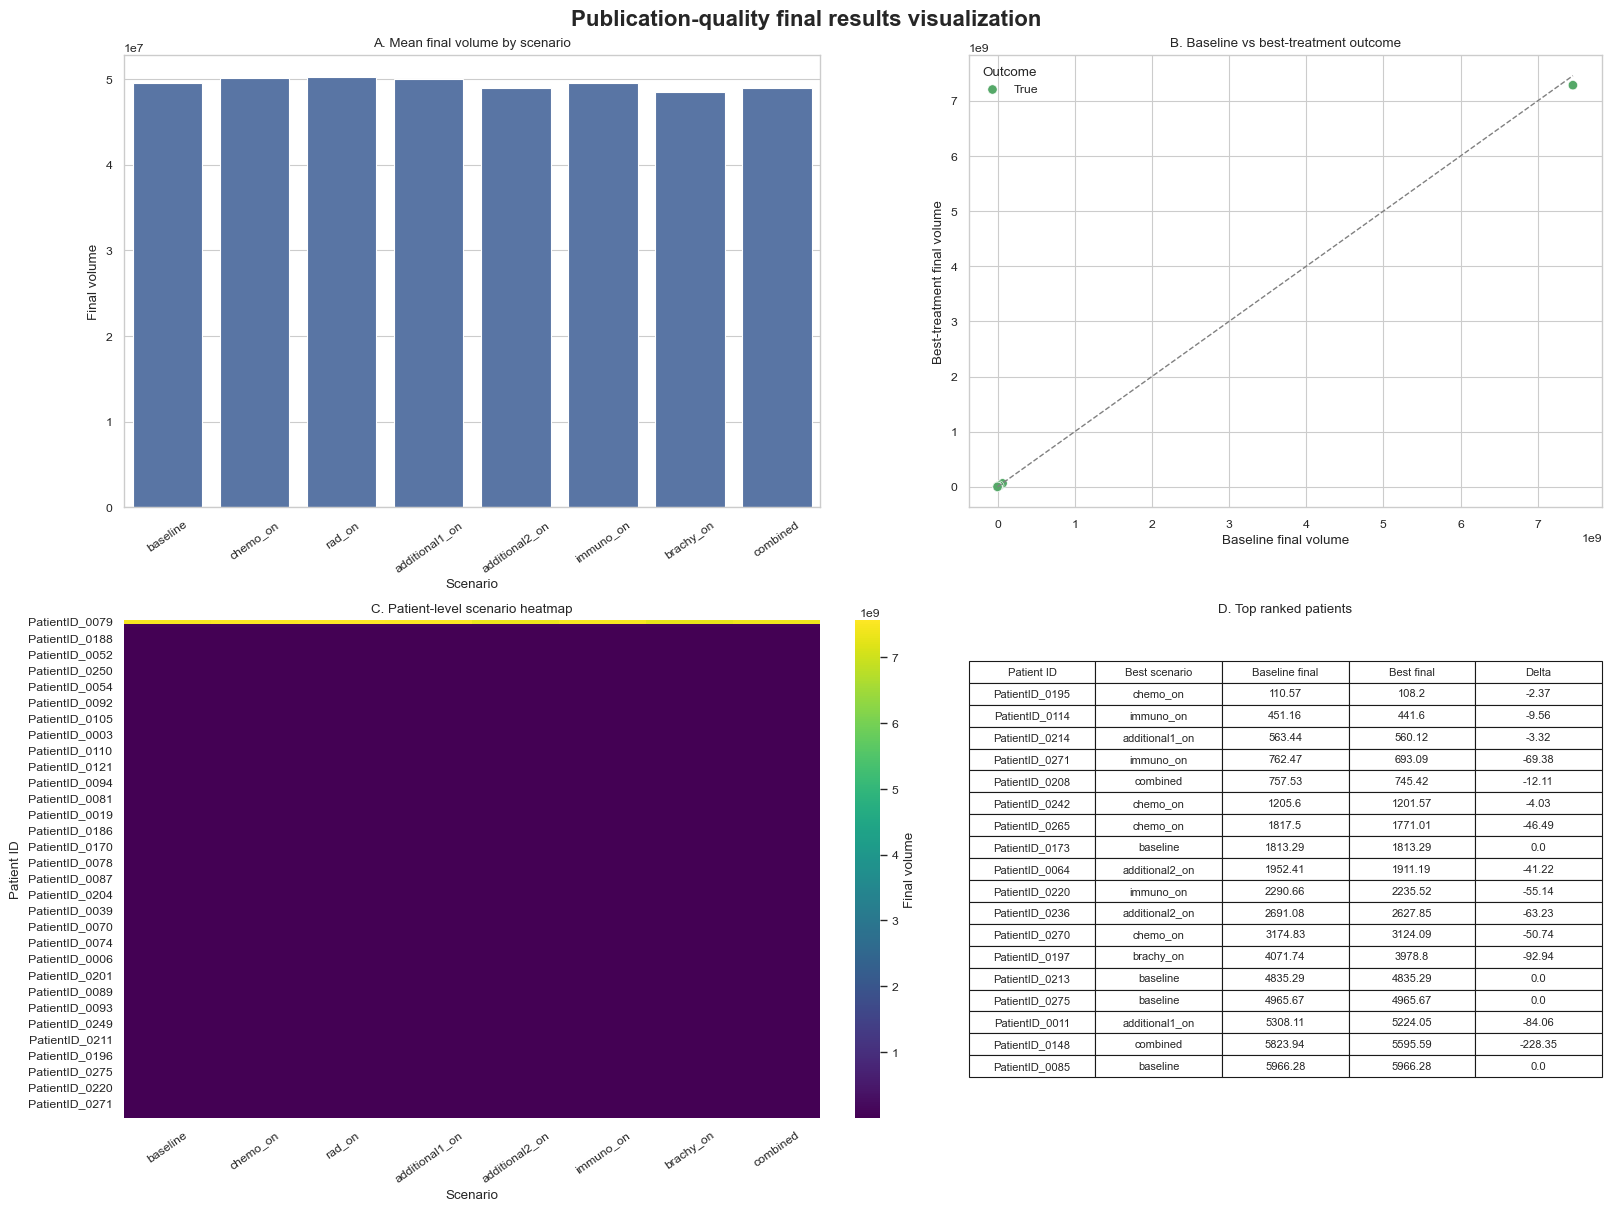

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec

best_by_patient = (
    df_forecast_metrics.sort_values(["Patient_ID", "Final_Volume_Total"], ascending=[True, True])
    .groupby("Patient_ID", as_index=False)
    .first()
    .copy()
)

baseline = (
    df_forecast_metrics[df_forecast_metrics["Scenario"] == "baseline"]
    [["Patient_ID", "Final_Volume_Total"]]
    .rename(columns={"Final_Volume_Total": "Baseline_Final"})
)

best = (
    best_by_patient[["Patient_ID", "Scenario", "Final_Volume_Total"]]
    .rename(columns={"Scenario": "Best_Scenario", "Final_Volume_Total": "Best_Final"})
)

comp = (
    best.merge(baseline, on="Patient_ID", how="left")
    .dropna(subset=["Baseline_Final", "Best_Final"])
    .copy()
)

comp["Delta"] = comp["Best_Final"] - comp["Baseline_Final"]
comp["Improved"] = comp["Delta"] <= 0

scenario_order = [
    "baseline", "chemo_on", "rad_on", "additional1_on",
    "additional2_on", "immuno_on", "brachy_on", "combined"
]

scenario_means = (
    df_forecast_metrics.groupby("Scenario", as_index=False)["Final_Volume_Total"].mean()
    .set_index("Scenario")
    .reindex(scenario_order)
    .dropna()
    .reset_index()
)

heat = df_forecast_metrics.pivot_table(
    index="Patient_ID",
    columns="Scenario",
    values="Final_Volume_Total",
    aggfunc="mean"
)
heat = heat.reindex(columns=[c for c in scenario_order if c in heat.columns])
if len(heat.columns) > 0:
    heat = heat.sort_values(by=heat.columns[0], ascending=False)

sns.set_theme(style="whitegrid", context="paper", font_scale=1.0)

fig = plt.figure(figsize=(16, 12), constrained_layout=True)
gs = GridSpec(2, 2, figure=fig, height_ratios=[1, 1.1], width_ratios=[1.1, 1])

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

sns.barplot(data=scenario_means, x="Scenario", y="Final_Volume_Total", ax=ax1, color="#4C72B0")
ax1.set_title("A. Mean final volume by scenario")
ax1.set_xlabel("Scenario")
ax1.set_ylabel("Final volume")
ax1.tick_params(axis="x", rotation=35)

sns.scatterplot(
    data=comp,
    x="Baseline_Final",
    y="Best_Final",
    hue="Improved",
    palette={True: "#55A868", False: "#C44E52"},
    s=45,
    ax=ax2,
    edgecolor="white",
    linewidth=0.4
)
mn = np.nanmin([comp["Baseline_Final"].min(), comp["Best_Final"].min()])
mx = np.nanmax([comp["Baseline_Final"].max(), comp["Best_Final"].max()])
ax2.plot([mn, mx], [mn, mx], "--", color="gray", linewidth=1)
ax2.set_title("B. Baseline vs best-treatment outcome")
ax2.set_xlabel("Baseline final volume")
ax2.set_ylabel("Best-treatment final volume")
ax2.legend(title="Outcome", frameon=False, loc="best")

if not heat.empty:
    sns.heatmap(heat, cmap="viridis", ax=ax3, cbar_kws={"label": "Final volume"})
    ax3.set_title("C. Patient-level scenario heatmap")
    ax3.set_xlabel("Scenario")
    ax3.set_ylabel("Patient ID")
    ax3.tick_params(axis="x", rotation=35)
else:
    ax3.axis("off")
    ax3.text(0.5, 0.5, "No heatmap data available", ha="center", va="center")

ax4.axis("off")
summary_table = (
    comp[["Patient_ID", "Best_Scenario", "Baseline_Final", "Best_Final", "Delta"]]
    .sort_values("Best_Final")
    .head(18)
    .copy()
)
summary_table[["Baseline_Final", "Best_Final", "Delta"]] = summary_table[["Baseline_Final", "Best_Final", "Delta"]].round(2)
summary_table.columns = ["Patient ID", "Best scenario", "Baseline final", "Best final", "Delta"]

tbl = ax4.table(
    cellText=summary_table.values,
    colLabels=summary_table.columns,
    loc="center",
    cellLoc="center"
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
tbl.scale(1, 1.4)
ax4.set_title("D. Top ranked patients")

fig.suptitle("Publication-quality final results visualization", fontsize=16, fontweight="bold")

#fig.savefig("publication_results_figure.png", dpi=300, bbox_inches="tight")
#fig.savefig("publication_results_figure.pdf", bbox_inches="tight")

#comp.to_csv("vht_baseline_vs_best_comparison.csv", index=False)
#scenario_means.to_csv("vht_scenario_means.csv", index=False)
#summary_table.to_csv("vht_top_ranked_patients.csv", index=False)

plt.show()